# Stiffness measurement processing

Merge stiffness measurements with pathologist spot annotations, keep a target annotation class (e.g. `Stroma`), remove statistical outliers per capture spot using MAD/CV filtering, and write the cleaned measurements to a TSV file. Also produces a QC histogram of the number of measurements per capture spot.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from pathlib import Path
from matplotlib.ticker import MaxNLocator
import matplotlib as mpl
from sklearn.preprocessing import RobustScaler

new_rc_params = {'text.usetex': False, "svg.fonttype": 'none'}
mpl.rcParams.update(new_rc_params)

## Parameters

In [32]:
# --- Input paths ---
#  File with stiffness measurements
stiffness_file = Path('../Inputs/Mapped_Filtered_AFM_Measurements.csv')

# Directory containing per-section pathologist annotation CSV files
annotation_dir = Path('../Inputs/Spot_Annotation')

# --- Output paths ---
# Where to write the filtered measurements TSV file
output_tsv = Path('../Outputs/filtered_measurements.tsv')

# Where to save the QC histogram
output_fig = Path('../Outputs/QC_Hist.svg')

# --- Analysis settings ---
annotation_label = "Stroma"             # pathologist annotation label to keep
value_column = "Young's_modulus_[Pa]"   # numeric measurement column to filter on
radius = 50                             # radius of the spot area 
min_measurements = 2                    # minimum number of measurements a spot must have to be kept
mad_threshold = 3.5                     # modified z-score threshold (spots with > 2 measurements)
cv_threshold = 40                       # coefficient-of-variation %% threshold (spots with exactly 2 measurements)

## Load and merge data

In [22]:
# Read stiffness measurements
df = pd.read_csv(stiffness_file)

In [23]:
# Add section (sample) to the barcode
df['Barcode'] = df['Sample'] + '_' + df['Barcode']

In [25]:
# Keep measurements within the spot area
df=df[df['Distance_um']<=radius]

In [26]:
# Add spot pathologist annotation
def load_and_annotate_csv_files(folder_path):
    """Load per-section annotation CSV files and prefix barcodes with the section name.

    Each CSV file is expected to be named like '<prefix>_something.csv' and to
    contain two columns (Barcode, Annotation) with a header row.
    """
    csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {folder_path}")

    annotated_dfs = []
    for csv_file in csv_files:
        file_df = pd.read_csv(os.path.join(folder_path, csv_file), names=['Barcode', 'Annotation'], skiprows=1)
        prefix = csv_file.split('_')[0]
        file_df['Barcode'] = file_df['Barcode'].apply(lambda x: f"{prefix}_{x}")
        annotated_dfs.append(file_df)

    return pd.concat(annotated_dfs, ignore_index=True)

# Load and annotate the CSV files
annotated_df = load_and_annotate_csv_files(annotation_dir)

In [29]:
# Merge with combined_df on the 'Barcode' column
combined_df = pd.merge(df, annotated_df, on='Barcode', how='left')

# Keep only the target annotation label
combined_df = combined_df[combined_df['Annotation'] == annotation_label]
combined_df = combined_df.reset_index(drop=True)
combined_df

,Sample,ROI,Position_Index,Young's_modulus_[Pa],ResidualRMS_[N],Spot X,Spot Y,AFM X,AFM Y,Distance_um,Barcode,x_final,y_final,std_x,std_y,x_dif,y_dif,Distance,Stable_0.5sigma,Annotation
0,Patient01,ROI01,3,41.7625,9.720000e-12,8406,5591,8360.397265,5609.976863,36.230933,Patient01_CGCCATCCGATTATGA-1,8360.291276,5609.708570,20.673675,20.677383,0.105989,0.268293,49.393631,True,Stroma
1,Patient01,ROI01,4,911.0730,4.080000e-11,8406,5591,8374.240319,5588.448103,23.371260,Patient01_CGCCATCCGATTATGA-1,8374.133486,5588.181061,20.799931,20.802935,0.106833,0.267042,31.862039,True,Stroma
2,Patient01,ROI01,5,118.0150,1.270000e-11,8406,5591,8388.083373,5566.919343,22.016227,Patient01_CGCCATCCGATTATGA-1,8387.975696,5566.653553,20.928402,20.930842,0.107677,0.265790,30.014722,True,Stroma
3,Patient01,ROI01,6,69.7739,1.020000e-11,8406,5591,8401.926427,5545.390583,33.588329,Patient01_CGCCATCCGATTATGA-1,8401.817907,5545.126044,21.059048,21.061061,0.108521,0.264539,45.790970,True,Stroma
4,Patient01,ROI01,8,57.2718,1.070000e-11,8409,5453,8429.612535,5502.333063,39.218174,Patient01_TGTTGTCAAGAAGTCT-1,8429.502327,5502.071027,21.326704,21.328267,0.110209,0.262036,53.466137,True,Stroma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3036,Patient7a,ROI02,88,48.4956,8.941460e-12,9186,7688,9170.552739,7712.991993,21.551064,Patient7a_CAACTCCTTGATCCCG-1,9170.552742,7712.991989,17.940877,17.936875,-0.000003,0.000004,29.380565,True,Stroma
3037,Patient7a,ROI02,89,113.5430,1.029680e-11,9186,7688,9196.093415,7717.803996,23.081297,Patient7a_CAACTCCTTGATCCCG-1,9196.093417,7717.803992,18.172575,18.167918,-0.000003,0.000004,31.466732,True,Stroma
3038,Patient7a,ROI02,90,3160.6300,2.272230e-11,9186,7688,9190.114366,7742.467173,40.066272,Patient7a_CAACTCCTTGATCCCG-1,9190.114368,7742.467169,18.200538,18.195166,-0.000003,0.000004,54.622349,True,Stroma
3039,Patient7a,ROI02,98,340.3170,1.223920e-11,8945,7686,8985.788961,7703.971150,32.694513,Patient7a_CCAATTGAATGTTAAT-1,8985.788963,7703.971146,16.530424,16.525038,-0.000003,0.000004,44.572430,True,Stroma


## QC: measurements per spot

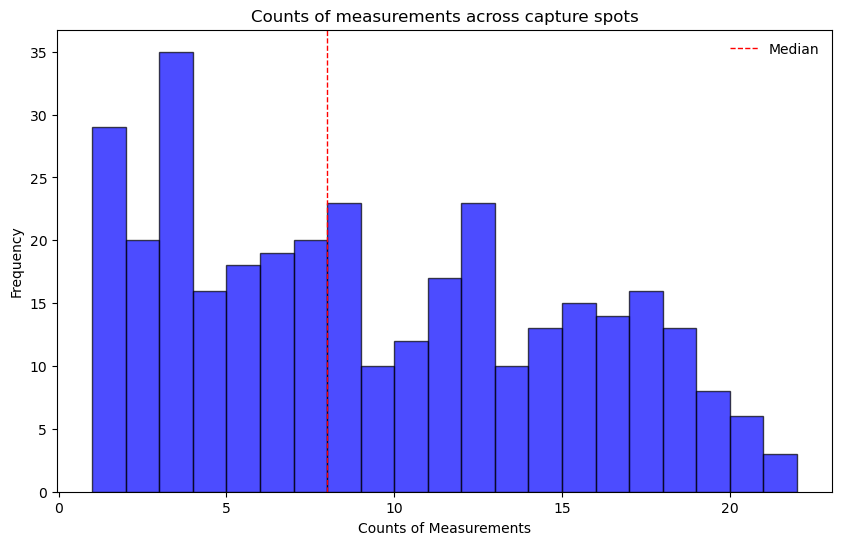

In [30]:
# Plot measurements per spot
# Count the occurrences of each unique barcode
barcode_counts = combined_df['Barcode'].value_counts()

# Calculate the median of the counts
median_count = barcode_counts.median()

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(barcode_counts, bins=range(1, barcode_counts.max() + 2), alpha=0.7, color='blue', edgecolor='black')
plt.axvline(median_count, color='red', linestyle='dashed', linewidth=1, label='Median')
plt.title('Counts of measurements across capture spots')
plt.xlabel('Counts of Measurements')
plt.ylabel('Frequency')
plt.legend(frameon=False)

if output_fig is not None:
    output_fig.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_fig)

plt.show()

In [31]:
# Calculate the counts of each unique value in the 'Barcode' column
barcode_counts = combined_df['Barcode'].value_counts()

# Identify barcodes that appear fewer times than the minimum required
barcodes_to_keep = barcode_counts[barcode_counts >= min_measurements].index

# Keep rows where the 'Barcode' value appears the minimum number of times or more
df = combined_df[combined_df['Barcode'].isin(barcodes_to_keep)]

# Filtering of measurements based on MAD and CV

In [34]:
# Function to compute Median Absolute Deviation (MAD) based outliers
def apply_mad(dataframe, column, threshold=mad_threshold):
    """Flag rows in `dataframe[column]` whose modified z-score exceeds `threshold`."""
    # Scale data using RobustScaler
    scaler = RobustScaler()
    reshaped_data = dataframe[column].values.reshape(-1, 1)
    scaled_data = scaler.fit_transform(reshaped_data)

    # Calculate MAD
    median = np.median(scaled_data)
    diff = np.abs(scaled_data - median)
    mad = np.median(diff)

    if mad == 0:
        # Avoid division by zero when all values are identical
        return dataframe.iloc[0:0]

    # Define outliers as those where the deviation is more than 'threshold' times the MAD
    modified_z_score = 0.6745 * diff / mad
    return dataframe[modified_z_score.flatten() > threshold]

# Function to compute Coefficient of Variation (CV) based filtering for two measurements
def apply_cv_filter(dataframe, column, cv_threshold):
    """Flag a pair of measurements as outliers if their CV exceeds `cv_threshold`."""
    mean_value = np.mean(dataframe[column])
    std_dev = np.std(dataframe[column])
    cv = std_dev * 100 / mean_value if mean_value != 0 else 0
    if cv > cv_threshold:
        # If the CV is too high, consider both points as outliers
        return dataframe  # Return both measurements
    else:
        return pd.DataFrame()  # No outliers

unique_barcodes = df['Barcode'].unique()
# Collect non-outlier data
filtered_chunks = []

for barcode in unique_barcodes:
    data = df[df['Barcode'] == barcode]
    # Remove outliers using MAD value if more than 2 measurements
    if len(data) > 2:
        outliers_df = apply_mad(data, value_column, threshold=mad_threshold)
        data = data[~data.index.isin(outliers_df.index)]
        filtered_chunks.append(data)
    elif len(data) == 2:  # If there are exactly 2 measurements, apply CV-based filter
        outliers_df = apply_cv_filter(data, value_column, cv_threshold=cv_threshold)
        data = data[~data.index.isin(outliers_df.index)]
        filtered_chunks.append(data)
    else:
        filtered_chunks.append(data)

filtered_data = pd.concat(filtered_chunks, ignore_index=True) if filtered_chunks else df.iloc[0:0]
filtered_data

,Sample,ROI,Position_Index,Young's_modulus_[Pa],ResidualRMS_[N],Spot X,Spot Y,AFM X,AFM Y,Distance_um,Barcode,x_final,y_final,std_x,std_y,x_dif,y_dif,Distance,Stable_0.5sigma,Annotation
0,Patient01,ROI01,3,41.7625,9.720000e-12,8406,5591,8360.397265,5609.976863,36.230933,Patient01_CGCCATCCGATTATGA-1,8360.291276,5609.708570,20.673675,20.677383,0.105989,0.268293,49.393631,True,Stroma
1,Patient01,ROI01,5,118.0150,1.270000e-11,8406,5591,8388.083373,5566.919343,22.016227,Patient01_CGCCATCCGATTATGA-1,8387.975696,5566.653553,20.928402,20.930842,0.107677,0.265790,30.014722,True,Stroma
2,Patient01,ROI01,6,69.7739,1.020000e-11,8406,5591,8401.926427,5545.390583,33.588329,Patient01_CGCCATCCGATTATGA-1,8401.817907,5545.126044,21.059048,21.061061,0.108521,0.264539,45.790970,True,Stroma
3,Patient01,ROI01,12,18.0129,9.460000e-12,8406,5591,8436.449503,5538.287066,44.653042,Patient01_CGCCATCCGATTATGA-1,8436.338937,5538.022900,21.106107,21.107481,0.110567,0.264166,60.875493,True,Stroma
4,Patient01,ROI01,14,21.4384,9.300000e-12,8406,5591,8408.763395,5581.344586,7.366739,Patient01_CGCCATCCGATTATGA-1,8408.654516,5581.077917,20.840947,20.842892,0.108879,0.266669,10.043075,True,Stroma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,Patient7a,ROI02,79,764.4660,1.299240e-11,8945,7686,8972.206383,7649.832793,33.197126,Patient7a_CCAATTGAATGTTAAT-1,8972.206386,7649.832789,16.506984,16.503307,-0.000003,0.000004,45.257642,True,Stroma
2633,Patient7a,ROI02,80,1108.9600,2.707690e-11,8945,7686,8966.227334,7674.495970,17.710116,Patient7a_CCAATTGAATGTTAAT-1,8966.227337,7674.495966,16.426045,16.421225,-0.000003,0.000004,24.144200,True,Stroma
2634,Patient7a,ROI02,81,2534.6200,2.499500e-11,8945,7686,8991.768009,7679.307973,34.654415,Patient7a_CCAATTGAATGTTAAT-1,8991.768012,7679.307969,16.579380,16.575306,-0.000003,0.000004,47.244364,True,Stroma
2635,Patient7a,ROI02,98,340.3170,1.223920e-11,8945,7686,8985.788961,7703.971150,32.694513,Patient7a_CCAATTGAATGTTAAT-1,8985.788963,7703.971146,16.530424,16.525038,-0.000003,0.000004,44.572430,True,Stroma


## Save filtered measurements

In [35]:
output_tsv.parent.mkdir(parents=True, exist_ok=True)
filtered_data.to_csv(output_tsv, sep='\t', index=False)
print(f"Wrote {len(filtered_data)} filtered measurements to {output_tsv}")

Wrote 2637 filtered measurements to ../Outputs/filtered_measurements.tsv
